# Yellow Mask Detection for Parasite Identification with Artifact Filtering

This notebook:
1. Processes images to detect yellow-tinted parasites using HSV color space
2. Applies morphological operations to clean up detections
3. Filters parasites by size and shape characteristics
4. **Filters out microscope artifacts** - removes masks appearing at same location in >5 images
5. Saves only images containing real parasites (not artifacts) to output directory
6. Memory-efficient: processes one image at a time

**Key Feature**: Artifacts that appear in the same position across multiple images (likely microscope defects or dust) are automatically identified and removed.

In [6]:
import os
import cv2
import numpy as np
from pathlib import Path
import shutil
import matplotlib.pyplot as plt
from collections import defaultdict

## Step 1: Detection and Artifact Filtering Functions

In [7]:
def detect_yellow_parasites(image_path,
                            min_area=300,
                            max_area=5000):
    """
    Detect yellow-tinted parasites and return their coordinates.
    
    Args:
        image_path: Path to the image file
        min_area: Minimum contour area to consider
        max_area: Maximum contour area to consider
    
    Returns:
        boxes: list of bounding boxes (x, y, w, h)
        centroids: list of (cx, cy)
        mask: final binary mask
        has_parasites: boolean indicating if parasites were found
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return [], [], None, False
    
    # Convert to HSV color space
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Define yellow color range in HSV
    lower_yellow = np.array([15, 60, 50])
    upper_yellow = np.array([35, 255, 200])
    
    # Create mask for yellow regions
    mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
    
    # Morphological operations to clean up the mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    
    boxes = []
    centroids = []
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
        
        x, y, w, h = cv2.boundingRect(cnt)
        
        # Shape filter: elongated objects (parasites tend to be elongated)
        aspect_ratio = max(w, h) / (min(w, h) + 1e-5)
        if aspect_ratio < 1.5:
            continue
        
        cx = x + w // 2
        cy = y + h // 2
        
        boxes.append((x, y, w, h))
        centroids.append((cx, cy))
    
    has_parasites = len(boxes) > 0
    
    return boxes, centroids, mask, has_parasites




In [8]:
def are_centroids_close(c1, c2, tolerance=50):
    """
    Check if two centroids are within tolerance distance.
    Used to identify masks appearing at same location across images.
    
    Args:
        c1, c2: Tuples of (x, y) coordinates
        tolerance: Maximum pixel distance to consider as "same location"
    
    Returns:
        Boolean indicating if centroids are close
    """
    return abs(c1[0] - c2[0]) <= tolerance and abs(c1[1] - c2[1]) <= tolerance


def find_artifact_positions(all_detections, max_occurrences=5, tolerance=50):
    """
    Identify positions that appear in more than max_occurrences images.
    These are likely microscope artifacts, not parasites.
    
    Args:
        all_detections: List of detection results from all images
        max_occurrences: Maximum times a position can appear before being flagged
        tolerance: Pixel tolerance for considering positions as "same"
    
    Returns:
        Set of artifact centroid positions (rounded to tolerance grid)
    """
    # Track centroid occurrences across images
    position_counter = defaultdict(int)
    
    for detection in all_detections:
        for centroid in detection['centroids']:
            # Round to tolerance grid to group nearby positions
            grid_x = round(centroid[0] / tolerance) * tolerance
            grid_y = round(centroid[1] / tolerance) * tolerance
            position_key = (grid_x, grid_y)
            position_counter[position_key] += 1
    
    # Identify artifact positions (appearing in too many images)
    artifact_positions = {
        pos for pos, count in position_counter.items() 
        if count > max_occurrences
    }
    
    return artifact_positions

## Step 2: Process Directory with Artifact Filtering

Three-phase process:
1. Detect all parasites in all images
2. Identify artifact positions (appearing in >5 images)
3. Filter artifacts and save only images with real parasites

In [9]:
def process_directory_for_yellow_parasites(
    input_dir,
    min_area=300,
    max_area=5000,
    max_artifact_occurrences=5,
    position_tolerance=50
):
    """
    Process all images in a directory and save only those with yellow parasites.
    Filters out artifacts that appear at the same position in multiple images.
    Memory-efficient: processes one image at a time.
    
    Args:
        input_dir: Path to directory containing images
        min_area: Minimum parasite area
        max_area: Maximum parasite area
        max_artifact_occurrences: Max times a position can appear before being flagged as artifact
        position_tolerance: Pixel tolerance for considering positions as "same location"
        
    Returns:
        output_dir: Path to output directory
        results: List of detection results (after filtering artifacts)
    """
    input_path = Path(input_dir)
    parent_name = input_path.name
    parent_parent = input_path.parent
    
    # Create output directory with "yellow_" prefix
    output_dir = parent_parent / f"yellow_{parent_name}"
    output_dir.mkdir(exist_ok=True)
    
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
    image_files = [f for f in input_path.iterdir()
                   if f.suffix.lower() in image_extensions]
    
    print(f"Found {len(image_files)} images in {input_dir}")
    print(f"Phase 1: Detecting parasites in all images...")
    print("-" * 70)
    
    # PHASE 1: Detect parasites in all images
    all_detections = []
    
    for img_file in image_files:
        boxes, centroids, mask, has_parasites = detect_yellow_parasites(
            img_file,
            min_area=min_area,
            max_area=max_area
        )
        
        if has_parasites:
            all_detections.append({
                'filename': img_file.name,
                'filepath': img_file,
                'boxes': boxes,
                'centroids': centroids,
                'parasite_count': len(boxes)
            })
            print(f"✓ {img_file.name:50s} | Detected: {len(boxes)}")
        else:
            print(f"○ {img_file.name:50s} | No parasites detected")
    
    print("-" * 70)
    print(f"\nPhase 2: Identifying microscope artifacts...")
    
    # PHASE 2: Identify artifact positions
    artifact_positions = find_artifact_positions(
        all_detections, 
        max_occurrences=max_artifact_occurrences,
        tolerance=position_tolerance
    )
    
    print(f"  Found {len(artifact_positions)} artifact positions")
    print(f"  (positions appearing in >{max_artifact_occurrences} images)")
    print("\n" + "-" * 70)
    print("Phase 3: Filtering artifacts and saving clean images...")
    
    # PHASE 3: Filter artifacts and save clean results
    images_with_parasites = 0
    total_parasites_detected = 0
    total_artifacts_filtered = 0
    results = []
    
    for detection in all_detections:
        # Filter out artifact centroids
        filtered_boxes = []
        filtered_centroids = []
        
        for box, centroid in zip(detection['boxes'], detection['centroids']):
            # Check if this centroid is an artifact
            grid_x = round(centroid[0] / position_tolerance) * position_tolerance
            grid_y = round(centroid[1] / position_tolerance) * position_tolerance
            position_key = (grid_x, grid_y)
            
            if position_key not in artifact_positions:
                # Not an artifact, keep it
                filtered_boxes.append(box)
                filtered_centroids.append(centroid)
            else:
                total_artifacts_filtered += 1
        
        # Only save image if it still has parasites after filtering
        if len(filtered_centroids) > 0:
            output_path = output_dir / detection['filename']
            shutil.copy(detection['filepath'], output_path)
            
            images_with_parasites += 1
            total_parasites_detected += len(filtered_centroids)
            
            results.append({
                'filename': detection['filename'],
                'parasite_count': len(filtered_centroids),
                'boxes': filtered_boxes,
                'centroids': filtered_centroids,
                'artifacts_removed': detection['parasite_count'] - len(filtered_centroids)
            })
            
            artifacts_removed = detection['parasite_count'] - len(filtered_centroids)
            status = f"Parasites: {len(filtered_centroids)}"
            if artifacts_removed > 0:
                status += f" (filtered {artifacts_removed} artifacts)"
            print(f"✓ {detection['filename']:50s} | {status}")
        else:
            print(f"✗ {detection['filename']:50s} | All detections were artifacts")
    
    print("-" * 70)
    print(f"\n✓ Processing complete!")
    print(f"  Total images processed: {len(image_files)}")
    print(f"  Initial detections: {len(all_detections)} images")
    print(f"  After artifact filtering: {images_with_parasites} images")
    print(f"  Images rejected (all artifacts): {len(all_detections) - images_with_parasites}")
    print(f"  Total parasites detected: {total_parasites_detected}")
    print(f"  Total artifacts filtered: {total_artifacts_filtered}")
    print(f"  Percentage with real parasites: {images_with_parasites/len(image_files)*100:.1f}%")
    print(f"\n  Output directory: {output_dir}")
    
    return output_dir, results

In [ ]:
# ============================================
# CONFIGURATION
# ============================================
INPUT_DIR = "../IB_155"  # Change this to your input directory
MIN_AREA = 2500  # Minimum parasite area in pixels
MAX_AREA = 80000  # Maximum parasite area in pixels
MAX_ARTIFACT_OCCURRENCES = 5  # Max times a position can appear before being flagged as artifact
POSITION_TOLERANCE = 50  # Pixel tolerance for considering positions as "same location"

# Process images and save those with yellow parasites (with artifact filtering)
output_dir, detection_results = process_directory_for_yellow_parasites(
    INPUT_DIR,
    min_area=MIN_AREA,
    max_area=MAX_AREA,
    max_artifact_occurrences=MAX_ARTIFACT_OCCURRENCES,
    position_tolerance=POSITION_TOLERANCE
)

Found 3938 images in ../AS_160
Phase 1: Detecting parasites in all images...
----------------------------------------------------------------------
○ 2024-03-12_03-28-55-851317.jpg                     | No parasites detected
○ 2024-03-12_03-59-46-127175.jpg                     | No parasites detected
○ 2024-03-12_03-43-27-396337.jpg                     | No parasites detected
○ 2024-03-12_04-17-11-213373.jpg                     | No parasites detected
○ 2024-03-12_04-27-58-508285.jpg                     | No parasites detected
○ 2024-03-12_03-20-19-678077.jpg                     | No parasites detected
○ 2024-03-12_03-47-29-489257.jpg                     | No parasites detected
○ 2024-03-12_04-16-01-019664.jpg                     | No parasites detected
○ 2024-03-12_03-45-14-778421.jpg                     | No parasites detected
○ 2024-03-12_04-22-15-989148.jpg                     | No parasites detected
○ 2024-03-12_03-22-27-307489.jpg                     | No parasites detected
○ 202

## Step 3: View Artifact Filtering Statistics

In [16]:
if detection_results:
    # Calculate artifact filtering statistics
    total_artifacts_removed = sum(r.get('artifacts_removed', 0) for r in detection_results)
    images_with_artifacts = sum(1 for r in detection_results if r.get('artifacts_removed', 0) > 0)
    
    print("="*70)
    print("ARTIFACT FILTERING SUMMARY")
    print("="*70)
    print(f"Total artifacts filtered out: {total_artifacts_removed}")
    print(f"Images with artifacts removed: {images_with_artifacts}")
    print(f"Images with only real parasites: {len(detection_results) - images_with_artifacts}")
    
    if images_with_artifacts > 0:
        print(f"\nTop images with most artifacts removed:")
        top_filtered = sorted(detection_results, 
                            key=lambda x: x.get('artifacts_removed', 0), 
                            reverse=True)[:10]
        
        for i, result in enumerate(top_filtered[:10], 1):
            artifacts = result.get('artifacts_removed', 0)
            if artifacts > 0:
                print(f"  {i:2d}. {result['filename']:40s} | "
                      f"Kept: {result['parasite_count']}, Filtered: {artifacts}")
else:
    print("No detections after artifact filtering.")

ARTIFACT FILTERING SUMMARY
Total artifacts filtered out: 0
Images with artifacts removed: 0
Images with only real parasites: 9


## Step 4: Visualize Detection Statistics

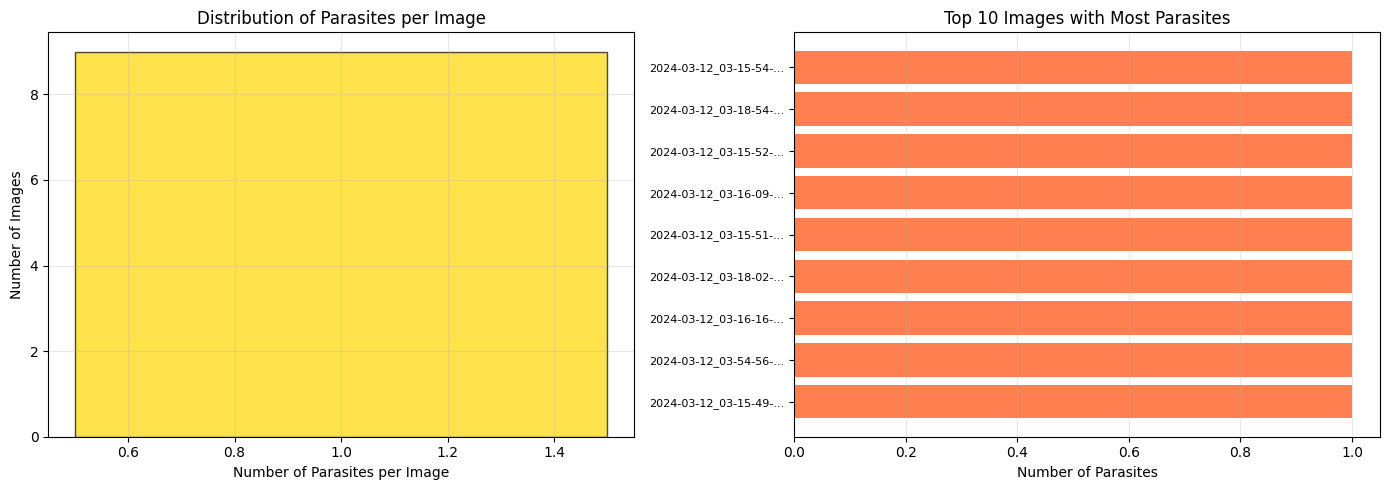


Detection Statistics:
  Total images with parasites: 9
  Average parasites per image: 1.00
  Median parasites per image: 1
  Max parasites in single image: 1
  Min parasites in detected images: 1


In [17]:


if detection_results:
    # Extract parasite counts
    parasite_counts = [r['parasite_count'] for r in detection_results]
    
    # Create visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Distribution of parasite counts
    axes[0].hist(parasite_counts, bins=max(parasite_counts), 
                 edgecolor='black', alpha=0.7, color='gold')
    axes[0].set_xlabel('Number of Parasites per Image')
    axes[0].set_ylabel('Number of Images')
    axes[0].set_title('Distribution of Parasites per Image')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Bar chart of top 10 images with most parasites
    top_10 = sorted(detection_results, key=lambda x: x['parasite_count'], reverse=True)[:10]
    filenames = [r['filename'][:20] + '...' if len(r['filename']) > 20 else r['filename'] 
                 for r in top_10]
    counts = [r['parasite_count'] for r in top_10]
    
    axes[1].barh(range(len(filenames)), counts, color='coral')
    axes[1].set_yticks(range(len(filenames)))
    axes[1].set_yticklabels(filenames, fontsize=8)
    axes[1].set_xlabel('Number of Parasites')
    axes[1].set_title('Top 10 Images with Most Parasites')
    axes[1].invert_yaxis()
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    print("\nDetection Statistics:")
    print(f"  Total images with parasites: {len(detection_results)}")
    print(f"  Average parasites per image: {np.mean(parasite_counts):.2f}")
    print(f"  Median parasites per image: {np.median(parasite_counts):.0f}")
    print(f"  Max parasites in single image: {max(parasite_counts)}")
    print(f"  Min parasites in detected images: {min(parasite_counts)}")
else:
    print("No parasites detected in any images.")

## Step 5 (Optional): Visualize Sample Detections

View images with detected parasites and their bounding boxes (after artifact removal)

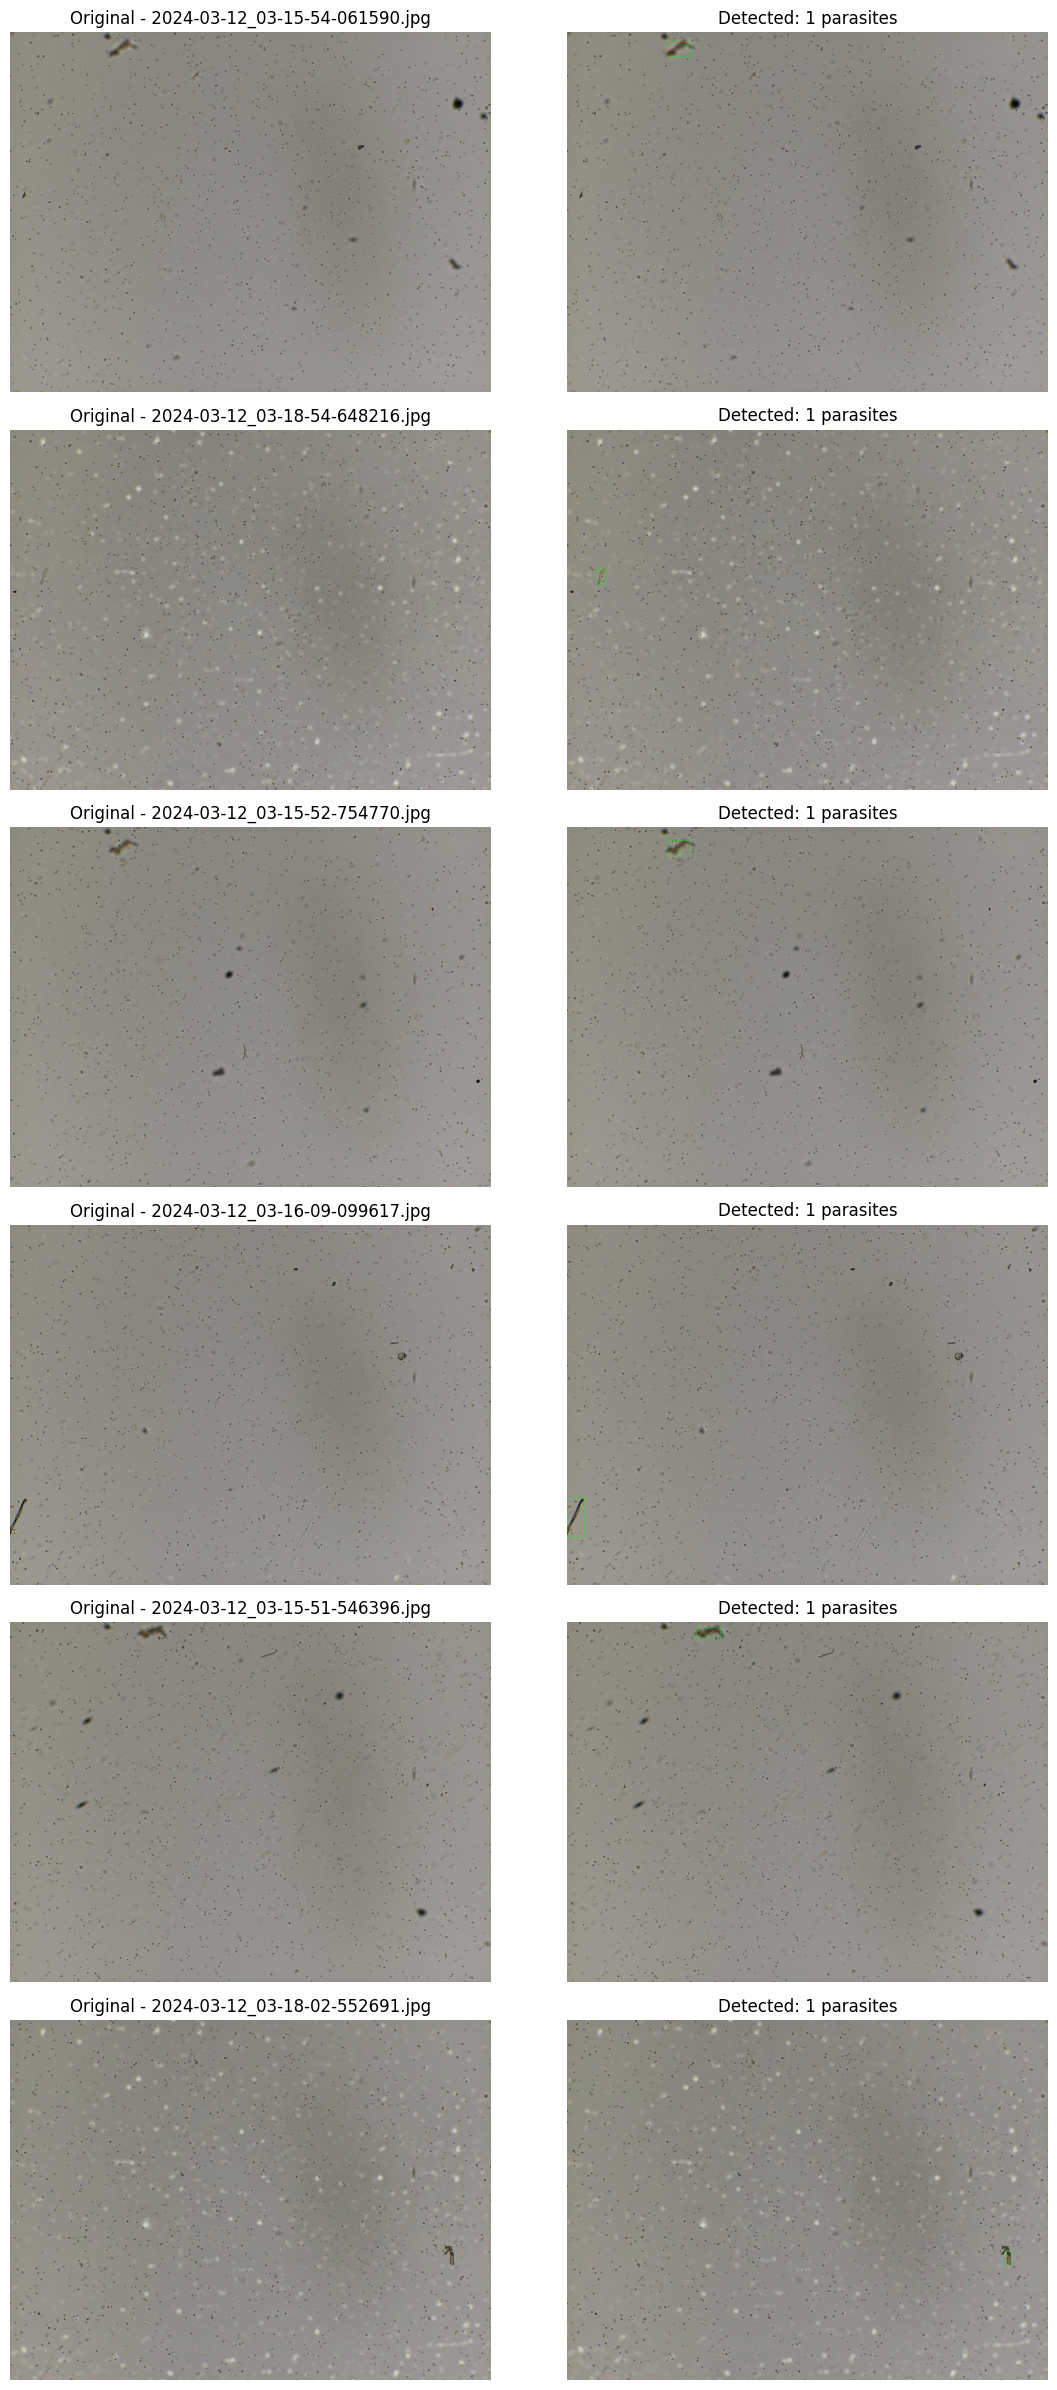

Showing top 6 images with most parasites


In [18]:
if detection_results:
    # Select top 6 images with most parasites
    top_images = sorted(detection_results, key=lambda x: x['parasite_count'], reverse=True)[:6]
    
    num_images = len(top_images)
    fig, axes = plt.subplots(num_images, 2, figsize=(12, 4*num_images))
    
    # Handle case where there's only one image
    if num_images == 1:
        axes = axes.reshape(1, -1)
    
    for idx, result in enumerate(top_images):
        # Read original image
        img_path = Path(output_dir) / result['filename']
        img = cv2.imread(str(img_path))
        
        if img is None:
            continue
        
        # Create annotated version
        img_annotated = img.copy()
        
        # Draw bounding boxes and centroids
        for (x, y, w, h), (cx, cy) in zip(result['boxes'], result['centroids']):
            cv2.rectangle(img_annotated, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.circle(img_annotated, (cx, cy), 3, (0, 0, 255), -1)
        
        # Convert BGR to RGB for matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_annotated_rgb = cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB)
        
        # Display original
        axes[idx, 0].imshow(img_rgb)
        axes[idx, 0].set_title(f"Original - {result['filename'][:30]}")
        axes[idx, 0].axis('off')
        
        # Display with detections
        axes[idx, 1].imshow(img_annotated_rgb)
        axes[idx, 1].set_title(f"Detected: {result['parasite_count']} parasites")
        axes[idx, 1].axis('off')
        
        # Free memory
        del img, img_annotated, img_rgb, img_annotated_rgb
    
    plt.tight_layout()
    plt.show()
    
    print(f"Showing top {num_images} images with most parasites")
else:
    print("No detections to visualize.")

## Step 6 (Optional): Fine-tune Detection Parameters

Adjust HSV ranges, size constraints, and artifact filtering thresholds

In [19]:
# Test detection on a single image with different parameters
test_image_path = Path(INPUT_DIR) / "2024-03-12_01-22-12-044496.jpg"  # Change to your test image

if test_image_path.exists():
    # Try different parameter combinations
    parameter_sets = [
        {"min_area": 200, "max_area": 5000, "label": "Smaller min (200)"},
        {"min_area": 300, "max_area": 5000, "label": "Default (300)"},
        {"min_area": 500, "max_area": 5000, "label": "Larger min (500)"},
    ]
    
    fig, axes = plt.subplots(1, len(parameter_sets), figsize=(15, 5))
    
    for idx, params in enumerate(parameter_sets):
        boxes, centroids, mask, has_parasites = detect_yellow_parasites(
            test_image_path,
            min_area=params["min_area"],
            max_area=params["max_area"]
        )
        
        img = cv2.imread(str(test_image_path))
        img_annotated = img.copy()
        
        # Draw detections
        for (x, y, w, h), (cx, cy) in zip(boxes, centroids):
            cv2.rectangle(img_annotated, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.circle(img_annotated, (cx, cy), 3, (0, 0, 255), -1)
        
        img_rgb = cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(img_rgb)
        axes[idx].set_title(f"{params['label']}\nDetected: {len(boxes)}")
        axes[idx].axis('off')
        
        del img, img_annotated, img_rgb
    
    plt.tight_layout()
    plt.show()
    
    print("\nParameter tuning guide:")
    print("\nDetection parameters:")
    print("  - Decrease min_area to detect smaller parasites")
    print("  - Increase min_area to filter out noise")
    print("  - Adjust HSV ranges in the function for different yellow shades")
    print("\nArtifact filtering parameters:")
    print(f"  - MAX_ARTIFACT_OCCURRENCES (current: {MAX_ARTIFACT_OCCURRENCES})")
    print("    Lower = more aggressive filtering (removes positions in fewer images)")
    print("    Higher = less aggressive (allows positions to appear in more images)")
    print(f"  - POSITION_TOLERANCE (current: {POSITION_TOLERANCE} pixels)")
    print("    Lower = stricter position matching (must be exact)")
    print("    Higher = looser position matching (nearby positions considered same)")
else:
    print(f"Test image not found: {test_image_path}")

Test image not found: ../AS_160/2024-03-12_01-22-12-044496.jpg
